# WK5: Real EMPCA Evaluation + Visualization (6 models)

This notebook combines:
- **real-data model evaluation flow** from `wk4/evaluate_EMPCA_6models_REIM_ridge.ipynb`
- **plot/table style** from `wk4/reim_visualization_samples.ipynb`

It evaluates 6 trained artifacts (3 noises x 2 weight types) and plots **measured** sigma/FWHM.
No placeholder/sample curves are used.


In [1]:
import re
import gc
import sys
import pickle
from pathlib import Path

import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def _repo_root():
    here = Path.cwd().resolve()
    cands = [here, here.parent, here.parent.parent]
    for c in cands:
        if (c / 'wk4').exists() and (c / 'reusable').exists():
            return c
        if (c / 'PCA_dev' / 'wk4').exists() and (c / 'PCA_dev' / 'reusable').exists():
            return c / 'PCA_dev'
    raise RuntimeError('Run this notebook from DELight_mtr, PCA_dev, or PCA_dev/wk5 directory.')


repo = _repo_root()
print('repo =', repo)

sys.path.insert(0, str(repo / 'reusable'))
from empca_TCY_optimized import ti_rfft

HAVE_OF = False
try:
    from OptimumFilter import OptimumFilter
    HAVE_OF = True
    print('OptimumFilter loaded from reusable/OptimumFilter.py')
except Exception as exc:
    print('OptimumFilter import failed; OF baselines disabled:', exc)

FIG_DIR = repo / 'wk5' / 'figures' / 'reim_viz_real_models'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('figure dir =', FIG_DIR)

MODELS_DIR = repo / 'wk4' / 'models'
FS = 3906250.0
VAL_FRAC = 0.30
SEED = 0

MODEL_FILES = [
    'PSD_run1_sum_mmc.pkl',
    'SNR2_run1_sum_mmc.pkl',
    'PSD_run1_sum_white.pkl',
    'SNR2_run1_sum_white.pkl',
    'PSD_run1_sum_pink.pkl',
    'SNR2_run1_sum_pink.pkl',
]

QP_TEMPLATE_CANDIDATES = [
    repo / 'reusable' / 'template' / 'qp_template.npy',
    repo / 'reusable' / 'template' / 'QP_template.npy',
    repo.parent / 'trigger_study' / 'archive' / 'wk9' / 'preliminary' / 'sum_qp_template_1800.npy',
]

NOISE_PSD_PATHS = {
    'mmc': Path('/ceph/dwong/delight/noise_psd_xray.npy'),
    'white': repo / 'reusable' / 'weight' / 'noise_psd_white.npy',
    'pink': repo / 'reusable' / 'weight' / 'noise_psd_pink.npy',
}

METHOD_REIM = 'k-PC Ridge (Re/Im)'
METHOD_EUCLID2 = 'Euclid-2 + Linear'
METHOD_OF = 'OF'
METHOD_OF_SHIFT = 'OF+shift'
METHOD_ORDER = [METHOD_OF, METHOD_OF_SHIFT, METHOD_REIM, METHOD_EUCLID2]

COLORS = {
    METHOD_OF: '#D1495B',
    METHOD_OF_SHIFT: '#EDAE49',
    METHOD_REIM: '#00798C',
    METHOD_EUCLID2: '#66A182',
    'PSD': '#2A9D8F',
    'SNR2': '#1D3557',
}

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})


repo = /home/dwong/DELight_mtr/PCA_dev
OptimumFilter loaded from reusable/OptimumFilter.py
figure dir = /home/dwong/DELight_mtr/PCA_dev/wk5/figures/reim_viz_real_models


In [2]:
def resolve_local_path(path_like):
    if path_like is None:
        return None
    p = Path(path_like)
    if p.exists():
        return p

    s = str(p)
    marker = 'PCA_dev/'
    if marker in s:
        suffix = s.split(marker, 1)[1]
        cand = repo / suffix
        if cand.exists():
            return cand
    return p


def choose_qp_template_path():
    for p in QP_TEMPLATE_CANDIDATES:
        if p.exists():
            return p
    return None


def preflight_checks():
    missing = []
    info = []

    artifacts = {}
    for name in MODEL_FILES:
        p = MODELS_DIR / name
        ok = p.exists()
        info.append(('model', str(p), ok))
        if not ok:
            missing.append(str(p))
            continue
        with open(p, 'rb') as f:
            artifacts[name] = pickle.load(f)

    data_paths = set()
    for name, art in artifacts.items():
        psd_path = resolve_local_path(art.get('psd_path'))
        snr_path = resolve_local_path(art.get('snr2_weight_path'))

        if psd_path is not None:
            ok = psd_path.exists()
            info.append(('psd', f'{name}: {psd_path}', ok))
            if not ok:
                missing.append(str(psd_path))

        if snr_path is not None:
            ok = snr_path.exists()
            info.append(('snr2', f'{name}: {snr_path}', ok))
            if not ok:
                missing.append(str(snr_path))

        for dp in art.get('dataset_paths', [])[:1]:
            data_paths.add(str(dp))

    for dp in sorted(data_paths):
        p = Path(dp)
        ok = p.exists()
        info.append(('data', str(p), ok))
        if not ok:
            missing.append(str(p))

    qp_path = choose_qp_template_path()
    if qp_path is None:
        info.append(('template', 'qp template (all candidates)', False))
        missing.append('qp template: none of candidates found')
    else:
        info.append(('template', str(qp_path), True))

    print('--- preflight checks ---')
    for kind, path, ok in info:
        tag = 'OK' if ok else 'MISSING'
        print(f'[{tag}] {kind:<8} {path}')

    print('missing_count =', len(set(missing)))
    return artifacts, sorted(set(missing)), qp_path


artifacts, missing_assets, qp_template_path = preflight_checks()
print('loaded_artifacts =', len(artifacts))
print('qp_template_path =', qp_template_path)


--- preflight checks ---
[OK] model    /home/dwong/DELight_mtr/PCA_dev/wk4/models/PSD_run1_sum_mmc.pkl
[OK] model    /home/dwong/DELight_mtr/PCA_dev/wk4/models/SNR2_run1_sum_mmc.pkl
[OK] model    /home/dwong/DELight_mtr/PCA_dev/wk4/models/PSD_run1_sum_white.pkl
[OK] model    /home/dwong/DELight_mtr/PCA_dev/wk4/models/SNR2_run1_sum_white.pkl
[OK] model    /home/dwong/DELight_mtr/PCA_dev/wk4/models/PSD_run1_sum_pink.pkl
[OK] model    /home/dwong/DELight_mtr/PCA_dev/wk4/models/SNR2_run1_sum_pink.pkl
[OK] psd      PSD_run1_sum_mmc.pkl: /ceph/dwong/delight/noise_psd_xray.npy
[OK] snr2     SNR2_run1_sum_mmc.pkl: /home/dwong/DELight_mtr/PCA_dev/reusable/weight/qp_snr2_weight_MMC.npy
[OK] psd      PSD_run1_sum_white.pkl: /home/dwong/DELight_mtr/PCA_dev/reusable/weight/noise_psd_white.npy
[OK] snr2     SNR2_run1_sum_white.pkl: /home/dwong/DELight_mtr/PCA_dev/reusable/weight/qp_snr2_weight_white.npy
[OK] psd      PSD_run1_sum_pink.pkl: /home/dwong/DELight_mtr/PCA_dev/reusable/weight/noise_psd_pi

In [3]:
def baseline_correct_per_trace(X_time, pretrigger=4000, method='mean'):
    X_time = np.asarray(X_time, dtype=np.float64)
    pre = X_time[:, :pretrigger]
    if method == 'mean':
        baseline = np.mean(pre, axis=1)
    elif method == 'median':
        baseline = np.median(pre, axis=1)
    else:
        raise ValueError("method must be 'mean' or 'median'")
    return X_time - baseline[:, None], baseline


def to_shift_invariant_spectrum(X_time):
    X_tilde = ti_rfft(X_time)
    if X_tilde.ndim != 2:
        raise RuntimeError('Unexpected output shape from ti_rfft')
    return X_tilde


def solve_linear_system(A, b, eps=1e-12):
    # Small dense solver (Gauss-Jordan with pivoting) to avoid np/scipy linalg OpenMP crashes.
    A = np.asarray(A, dtype=np.complex128).copy()
    b = np.asarray(b, dtype=np.complex128)

    vec_rhs = (b.ndim == 1)
    if vec_rhs:
        b = b[:, None]

    n = A.shape[0]
    if A.ndim != 2 or A.shape[1] != n:
        raise ValueError('A must be square')
    if b.shape[0] != n:
        raise ValueError('b has incompatible leading dimension')

    aug = np.concatenate([A, b.copy()], axis=1)

    for i in range(n):
        piv = i + int(np.argmax(np.abs(aug[i:, i])))
        piv_val = aug[piv, i]
        if np.abs(piv_val) <= eps:
            raise ValueError('Singular matrix in solve_linear_system')
        if piv != i:
            aug[[i, piv]] = aug[[piv, i]]

        aug[i, i:] = aug[i, i:] / aug[i, i]

        for r in range(n):
            if r == i:
                continue
            fac = aug[r, i]
            if fac != 0:
                aug[r, i:] = aug[r, i:] - fac * aug[i, i:]

    x = aug[:, n:]
    x = np.real_if_close(x, tol=1e5)
    if vec_rhs:
        return x[:, 0]
    return x


def project_coefficients(X_feat, eigvec, metric_weight):
    Phi = eigvec.T
    w = np.asarray(metric_weight, dtype=np.float64)

    Xw = X_feat * w[None, :]
    n_obs = Xw.shape[0]
    n_comp = Phi.shape[1]

    # A_ij = sum_f conj(Phi_fi) * w_f * Phi_fj
    A = np.empty((n_comp, n_comp), dtype=np.complex128)
    for i in range(n_comp):
        pi = np.conjugate(Phi[:, i])
        for j in range(n_comp):
            A[i, j] = np.sum(pi * (Phi[:, j] * w))

    # rhs_oj = sum_f Xw_of * conj(Phi_fj)
    rhs = np.empty((n_obs, n_comp), dtype=np.complex128)
    for j in range(n_comp):
        rhs[:, j] = np.sum(Xw * np.conjugate(Phi[:, j])[None, :], axis=1)

    coeff_t = solve_linear_system(A, rhs.T)
    coeff = coeff_t.T
    return coeff


def resolution_from_truth(y_est, y_true):
    resid = np.asarray(y_true) - np.asarray(y_est)
    sigma = np.std(resid, ddof=1)
    return float(sigma), float(2.355 * sigma)


def get_metric_weight(model_artifact):
    if model_artifact.get('psd_eff') is not None:
        psd_eff = np.asarray(model_artifact['psd_eff'], dtype=np.float64)
        return 1.0 / (psd_eff + 0.0)

    psd_path = resolve_local_path(model_artifact.get('psd_path'))
    if psd_path is not None and psd_path.exists():
        arr = np.load(psd_path)
        psd = arr[1] if arr.ndim == 2 and arr.shape[0] == 2 else arr
        return 1.0 / (np.asarray(psd, dtype=np.float64) + 0.0)

    snr_path = resolve_local_path(model_artifact.get('snr2_weight_path'))
    if snr_path is not None and snr_path.exists():
        return np.asarray(np.load(snr_path), dtype=np.float64)

    raise ValueError('No usable metric in model artifact')


def compute_coeff_for_model(model_artifact, X_time):
    pca = model_artifact['pca']
    cfg = model_artifact.get('cfg', {})
    pretrigger = int(cfg.get('pretrigger', 4000))
    baseline_method = cfg.get('baseline_method', 'mean')

    X0, _ = baseline_correct_per_trace(X_time, pretrigger=pretrigger, method=baseline_method)
    X_feat = to_shift_invariant_spectrum(X0)

    eigvec = pca.eigvec
    if X_feat.shape[1] != eigvec.shape[1]:
        raise ValueError(f'freq mismatch: {X_feat.shape[1]} vs {eigvec.shape[1]}')

    w = get_metric_weight(model_artifact)
    coeff = project_coefficients(X_feat, eigvec, w)
    return coeff


def make_train_val_idx(n, val_frac=0.3, seed=0):
    idx = np.arange(n)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    n_val = int(val_frac * n)
    val_idx = idx[:n_val]
    train_idx = idx[n_val:]
    return train_idx, val_idx


def lin_calibrate_train(x_train, y_train, x_eval):
    x_train = np.asarray(x_train, dtype=np.float64)
    y_train = np.asarray(y_train, dtype=np.float64)
    x_eval = np.asarray(x_eval, dtype=np.float64)

    xm = np.mean(x_train)
    ym = np.mean(y_train)
    dx = x_train - xm
    var = np.sum(dx * dx)

    if var <= 0:
        a = 0.0
    else:
        a = float(np.sum(dx * (y_train - ym)) / var)
    b = float(ym - a * xm)

    return a * x_eval + b, a, b


def make_reim_features(coeff, k):
    c = coeff[:, :k]
    return np.column_stack([c.real, c.imag])


def standardize(train, val):
    mu = np.mean(train, axis=0)
    sig = np.std(train, axis=0)
    sig[sig == 0] = 1.0
    return (train - mu) / sig, (val - mu) / sig


def ridge_predict(X_train, y_train, X_val, alpha):
    X_train = np.asarray(X_train, dtype=np.float64)
    y_train = np.asarray(y_train, dtype=np.float64)
    X_val = np.asarray(X_val, dtype=np.float64)

    X1 = np.column_stack([X_train, np.ones(X_train.shape[0])])
    XtX = np.einsum('ni,nj->ij', X1, X1, optimize=False)
    Xty = np.einsum('ni,n->i', X1, y_train, optimize=False)

    I = np.eye(X1.shape[1], dtype=np.float64)
    I[-1, -1] = 0.0

    w = solve_linear_system(XtX + float(alpha) * I, Xty)
    w = np.asarray(np.real_if_close(w), dtype=np.float64)

    Xv1 = np.column_stack([X_val, np.ones(X_val.shape[0])])
    return np.einsum('ni,i->n', Xv1, w, optimize=False)


def eval_euclid2_linear(coeff, y_true, train_idx, val_idx):
    amp2 = np.sqrt(np.sum(np.abs(coeff[:, :2]) ** 2, axis=1))
    y_est, a, b = lin_calibrate_train(amp2[train_idx], y_true[train_idx], amp2[val_idx])
    sigma, fwhm = resolution_from_truth(y_est, y_true[val_idx])
    return {
        'k': 2,
        'alpha': np.nan,
        'sigma': sigma,
        'fwhm': fwhm,
        'a': a,
        'b': b,
        'y_est': y_est,
    }


def best_reim_ridge(coeff, y_true, train_idx, val_idx, k_list=(1,2,3,4,5,6,7,8), alphas=None):
    if alphas is None:
        alphas = np.logspace(-8, 2, 11)

    best = None
    for k in k_list:
        X = make_reim_features(coeff, k)
        X_train, X_val = X[train_idx], X[val_idx]
        X_train, X_val = standardize(X_train, X_val)
        for alpha in alphas:
            y_est = ridge_predict(X_train, y_true[train_idx], X_val, float(alpha))
            sigma, fwhm = resolution_from_truth(y_est, y_true[val_idx])
            row = {
                'k': int(k),
                'alpha': float(alpha),
                'sigma': sigma,
                'fwhm': fwhm,
                'y_est': y_est,
            }
            if best is None or row['sigma'] < best['sigma']:
                best = row
    return best


def reim_sigma_vs_k(coeff, y_true, train_idx, val_idx, k_list=(1,2,3,4,5,6,7,8), alphas=None):
    if alphas is None:
        alphas = np.logspace(-8, 2, 11)

    rows = []
    for k in k_list:
        X = make_reim_features(coeff, k)
        X_train, X_val = X[train_idx], X[val_idx]
        X_train, X_val = standardize(X_train, X_val)

        best_k = None
        for alpha in alphas:
            y_est = ridge_predict(X_train, y_true[train_idx], X_val, float(alpha))
            sigma, fwhm = resolution_from_truth(y_est, y_true[val_idx])
            cand = {'k': int(k), 'alpha': float(alpha), 'sigma': sigma, 'fwhm': fwhm}
            if best_k is None or cand['sigma'] < best_k['sigma']:
                best_k = cand
        rows.append(best_k)
    return rows


def register_optimum_filter(noise_type, trace_len, pretrigger):
    if not HAVE_OF:
        return None, 'OptimumFilter unavailable'

    if qp_template_path is None:
        return None, 'qp_template_path is None'

    psd_path = NOISE_PSD_PATHS.get(noise_type, None)
    if psd_path is None:
        return None, f'No NOISE_PSD_PATHS entry for {noise_type}'
    if not Path(psd_path).exists():
        return None, f'Noise PSD missing: {psd_path}'

    template = np.asarray(np.load(qp_template_path), dtype=np.float64).squeeze()
    psd_arr = np.load(psd_path)
    psd = psd_arr[1] if psd_arr.ndim == 2 and psd_arr.shape[0] == 2 else psd_arr
    psd = np.asarray(psd, dtype=np.float64)

    if template.shape[0] != trace_len:
        return None, f'template length {template.shape[0]} != trace length {trace_len}'
    if psd.shape[0] != (trace_len // 2 + 1):
        return None, f'PSD length {psd.shape[0]} != expected {trace_len // 2 + 1}'

    t0 = template - np.mean(template[:pretrigger])
    of = OptimumFilter(t0, psd, FS)
    info = {
        'noise_type': noise_type,
        'template_path': str(qp_template_path),
        'noise_psd_path': str(psd_path),
    }
    return of, info


def load_noise_dataset(dataset_paths, trace_key, n_batches=None):
    files = [Path(p) for p in dataset_paths]
    files = sorted(files, key=lambda p: int(re.search(r'_batch_(\d+)', p.name).group(1)))
    if n_batches is not None:
        files = files[:n_batches]

    noisy_list = []
    clean_list = []
    for p in files:
        with h5py.File(p, 'r') as f:
            noisy_list.append(f[trace_key][:].astype(np.float64))
            clean_list.append(f['traces_clean'][:].astype(np.float64))

    X_noisy = np.concatenate(noisy_list, axis=0)[:, 0, :]
    X_clean = np.concatenate(clean_list, axis=0)[:, 0, :]
    return X_noisy, X_clean, files


## Evaluate Real Data (6 models + OF baselines)

This cell computes measured holdout sigma/FWHM for:
- `k-PC Ridge (Re/Im)` (best `k, alpha`)
- `Euclid-2 + Linear` (`k=2` norm baseline)
- `OF` and `OF+shift` baselines (duplicated across PSD/SNR2 columns for comparison)

OF registration uses `reusable/OptimumFilter.py` with:
- template: `qp_template_path`
- noise PSD: `NOISE_PSD_PATHS[noise]`

OF amplitudes are evaluated from both:
- `fit(trace)`
- `fit_with_shift(trace)`


In [4]:
models = {}
for name, art in artifacts.items():
    noise = art.get('noise_type', 'unknown')
    wt = art.get('weight_type', 'unknown')
    wlabel = 'SNR2' if ('SNR2' in wt or 'SNR2' in name) else 'PSD'
    models.setdefault(noise, {})[wlabel] = {'name': name, 'artifact': art}

print('noise groups:', sorted(models.keys()))
for n in sorted(models):
    print(n, '->', sorted(models[n].keys()))

rows_methods = []
rows_kcurve = []
of_noise_rows = []
of_shift_noise_rows = []
pred_store = {}

for noise in sorted(models):
    first = next(iter(models[noise].values()))['artifact']
    dataset_paths = first.get('dataset_paths', [])
    trace_key = first.get('trace_key', f'traces_{noise}')

    if not dataset_paths:
        print(f'[{noise}] no dataset paths in artifacts; skipping')
        continue

    X_noisy, X_clean, used_files = load_noise_dataset(dataset_paths, trace_key=trace_key)
    A_true = np.max(X_clean, axis=1)

    print(f'[{noise}] files={len(used_files)} traces={len(A_true)} trace_key={trace_key}')
    train_idx, val_idx = make_train_val_idx(len(A_true), val_frac=VAL_FRAC, seed=SEED)
    pretrigger = int(first.get('cfg', {}).get('pretrigger', 4000))

    # OF baselines once per noise (shared across PSD/SNR2)
    of_sigma = np.nan
    of_fwhm = np.nan
    of_shift_sigma = np.nan
    of_shift_fwhm = np.nan
    y_of = None
    y_of_shift = None

    X0, _ = baseline_correct_per_trace(X_noisy, pretrigger=pretrigger, method='mean')
    of_obj, of_info = register_optimum_filter(noise, trace_len=X0.shape[1], pretrigger=pretrigger)

    if of_obj is None:
        print(f'[{noise}] OF skipped: {of_info}')
    else:
        print(f"[{noise}] OF registered: template={of_info['template_path']} | psd={of_info['noise_psd_path']}")

        amp_of = np.empty(X0.shape[0], dtype=np.float64)
        amp_shift = np.empty(X0.shape[0], dtype=np.float64)
        for i in range(X0.shape[0]):
            # Requested OF amplitudes: fit(trace) and fit_with_shift(trace)
            a0, _ = of_obj.fit(X0[i])
            a1, _, _ = of_obj.fit_with_shift(X0[i])
            amp_of[i] = a0
            amp_shift[i] = a1

        y_of, a0, b0 = lin_calibrate_train(amp_of[train_idx], A_true[train_idx], amp_of[val_idx])
        of_sigma, of_fwhm = resolution_from_truth(y_of, A_true[val_idx])

        y_of_shift, a1, b1 = lin_calibrate_train(amp_shift[train_idx], A_true[train_idx], amp_shift[val_idx])
        of_shift_sigma, of_shift_fwhm = resolution_from_truth(y_of_shift, A_true[val_idx])

        of_noise_rows.append({'noise_type': noise, 'sigma': of_sigma, 'fwhm': of_fwhm, 'a': a0, 'b': b0})
        of_shift_noise_rows.append({'noise_type': noise, 'sigma': of_shift_sigma, 'fwhm': of_shift_fwhm, 'a': a1, 'b': b1})
        pred_store[(noise, 'OF')] = {'y_true': A_true[val_idx], 'y_est': y_of}
        pred_store[(noise, 'OF+shift')] = {'y_true': A_true[val_idx], 'y_est': y_of_shift}

    for wlabel in sorted(models[noise]):
        item = models[noise][wlabel]
        name = item['name']
        art = item['artifact']

        keep_mask = art.get('keep_mask', None)
        if keep_mask is not None and len(keep_mask) == len(A_true):
            X_eval = X_noisy[keep_mask]
            y_eval = A_true[keep_mask]
            tr, va = make_train_val_idx(len(y_eval), val_frac=VAL_FRAC, seed=SEED)
        else:
            X_eval = X_noisy
            y_eval = A_true
            tr, va = train_idx, val_idx

        coeff = compute_coeff_for_model(art, X_eval)

        eu2 = eval_euclid2_linear(coeff, y_eval, tr, va)
        rr = best_reim_ridge(coeff, y_eval, tr, va)
        k_rows = reim_sigma_vs_k(coeff, y_eval, tr, va)

        rows_methods.append({
            'model_file': name,
            'noise_type': noise,
            'weight_type': wlabel,
            'method': METHOD_EUCLID2,
            'k': eu2['k'],
            'alpha': eu2['alpha'],
            'sigma': eu2['sigma'],
            'fwhm': eu2['fwhm'],
        })
        rows_methods.append({
            'model_file': name,
            'noise_type': noise,
            'weight_type': wlabel,
            'method': METHOD_REIM,
            'k': rr['k'],
            'alpha': rr['alpha'],
            'sigma': rr['sigma'],
            'fwhm': rr['fwhm'],
        })

        for kr in k_rows:
            rows_kcurve.append({
                'noise_type': noise,
                'weight_type': wlabel,
                'model_file': name,
                'method': METHOD_REIM,
                'k': kr['k'],
                'alpha': kr['alpha'],
                'sigma': kr['sigma'],
                'fwhm': kr['fwhm'],
            })

        pred_store[(noise, wlabel, METHOD_REIM)] = {'y_true': y_eval[va], 'y_est': rr['y_est']}
        pred_store[(noise, wlabel, METHOD_EUCLID2)] = {'y_true': y_eval[va], 'y_est': eu2['y_est']}

        if np.isfinite(of_sigma):
            rows_methods.append({
                'model_file': 'OF',
                'noise_type': noise,
                'weight_type': wlabel,
                'method': METHOD_OF,
                'k': np.nan,
                'alpha': np.nan,
                'sigma': of_sigma,
                'fwhm': of_fwhm,
            })
        if np.isfinite(of_shift_sigma):
            rows_methods.append({
                'model_file': 'OF',
                'noise_type': noise,
                'weight_type': wlabel,
                'method': METHOD_OF_SHIFT,
                'k': np.nan,
                'alpha': np.nan,
                'sigma': of_shift_sigma,
                'fwhm': of_shift_fwhm,
            })

    del X_noisy, X_clean, A_true
    gc.collect()


df_methods = pd.DataFrame(rows_methods)
df_kcurve = pd.DataFrame(rows_kcurve)

display(df_methods.sort_values(['noise_type', 'weight_type', 'method']))
print('method rows =', len(df_methods), '| k-curve rows =', len(df_kcurve))


noise groups: ['mmc', 'pink', 'white']
mmc -> ['PSD', 'SNR2']
pink -> ['PSD', 'SNR2']
white -> ['PSD', 'SNR2']
[mmc] files=10 traces=1000 trace_key=traces_MMC
[mmc] OF registered: template=/home/dwong/DELight_mtr/PCA_dev/reusable/template/QP_template.npy | psd=/ceph/dwong/delight/noise_psd_xray.npy
[pink] files=10 traces=1000 trace_key=traces_pink
[pink] OF registered: template=/home/dwong/DELight_mtr/PCA_dev/reusable/template/QP_template.npy | psd=/home/dwong/DELight_mtr/PCA_dev/reusable/weight/noise_psd_pink.npy
[white] files=10 traces=1000 trace_key=traces_white
[white] OF registered: template=/home/dwong/DELight_mtr/PCA_dev/reusable/template/QP_template.npy | psd=/home/dwong/DELight_mtr/PCA_dev/reusable/weight/noise_psd_white.npy


,model_file,noise_type,weight_type,method,k,alpha,sigma,fwhm
0,PSD_run1_sum_mmc.pkl,mmc,PSD,Euclid-2 + Linear,2.0,NaN,12.337947,29.055866
2,OF,mmc,PSD,OF,NaN,NaN,7.816658,18.408230
3,OF,mmc,PSD,OF+shift,NaN,NaN,6.493218,15.291529
1,PSD_run1_sum_mmc.pkl,mmc,PSD,k-PC Ridge (Re/Im),2.0,1.000000e-08,7.393366,17.411377
4,SNR2_run1_sum_mmc.pkl,mmc,SNR2,Euclid-2 + Linear,2.0,NaN,20.357286,47.941408
6,OF,mmc,SNR2,OF,NaN,NaN,7.816658,18.408230
7,OF,mmc,SNR2,OF+shift,NaN,NaN,6.493218,15.291529
5,SNR2_run1_sum_mmc.pkl,mmc,SNR2,k-PC Ridge (Re/Im),8.0,1.000000e-08,5.677784,13.371182
8,PSD_run1_sum_pink.pkl,pink,PSD,Euclid-2 + Linear,2.0,NaN,27.191066,64.034960
10,OF,pink,PSD,OF,NaN,NaN,21.780283,51.292567


method rows = 24 | k-curve rows = 48


## Plot 1: Grouped Bar Chart (Real Sigma)


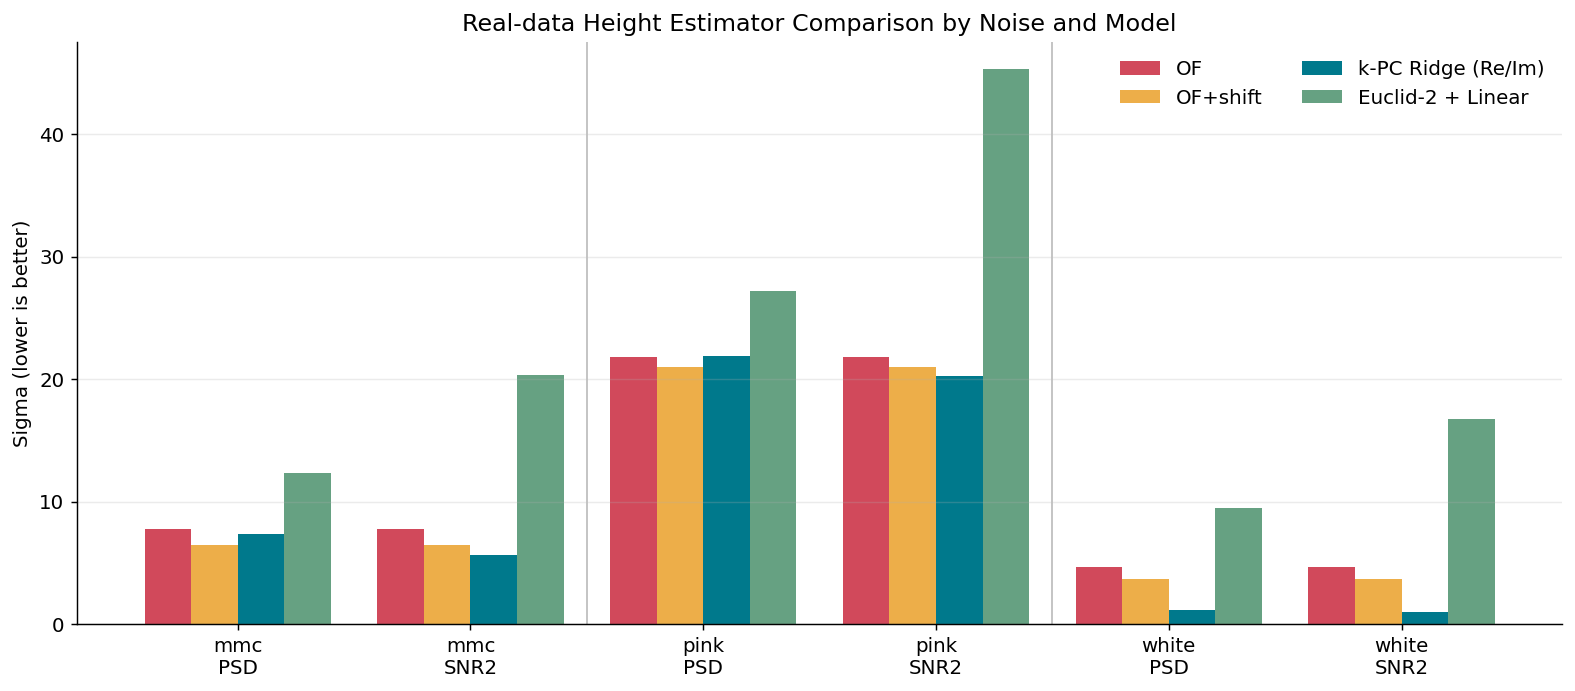

In [5]:
noise_order = ['mmc', 'pink', 'white']
model_order = ['PSD', 'SNR2']
group_keys = [(n, m) for n in noise_order for m in model_order]

x = np.arange(len(group_keys))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5.2), constrained_layout=True)

for i, method in enumerate(METHOD_ORDER):
    vals = []
    for n, m in group_keys:
        q = df_methods[(df_methods['noise_type'] == n) & (df_methods['weight_type'] == m) & (df_methods['method'] == method)]
        vals.append(float(q['sigma'].iloc[0]) if len(q) else np.nan)

    offset = (i - (len(METHOD_ORDER) - 1) / 2) * width
    ax.bar(x + offset, vals, width=width, label=method, color=COLORS[method])

for boundary in [1.5, 3.5]:
    ax.axvline(boundary, color='0.75', linewidth=1.0)

ax.set_xticks(x)
ax.set_xticklabels([f'{n}\n{m}' for n, m in group_keys])
ax.set_ylabel('Sigma (lower is better)')
ax.set_title('Real-data Height Estimator Comparison by Noise and Model')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False, ncol=2)

fig.savefig(FIG_DIR / 'real_bar_by_noise_model_methods.png', dpi=300)
plt.show()


## Plot 2: Sigma vs k (Real REIM, best alpha per k)


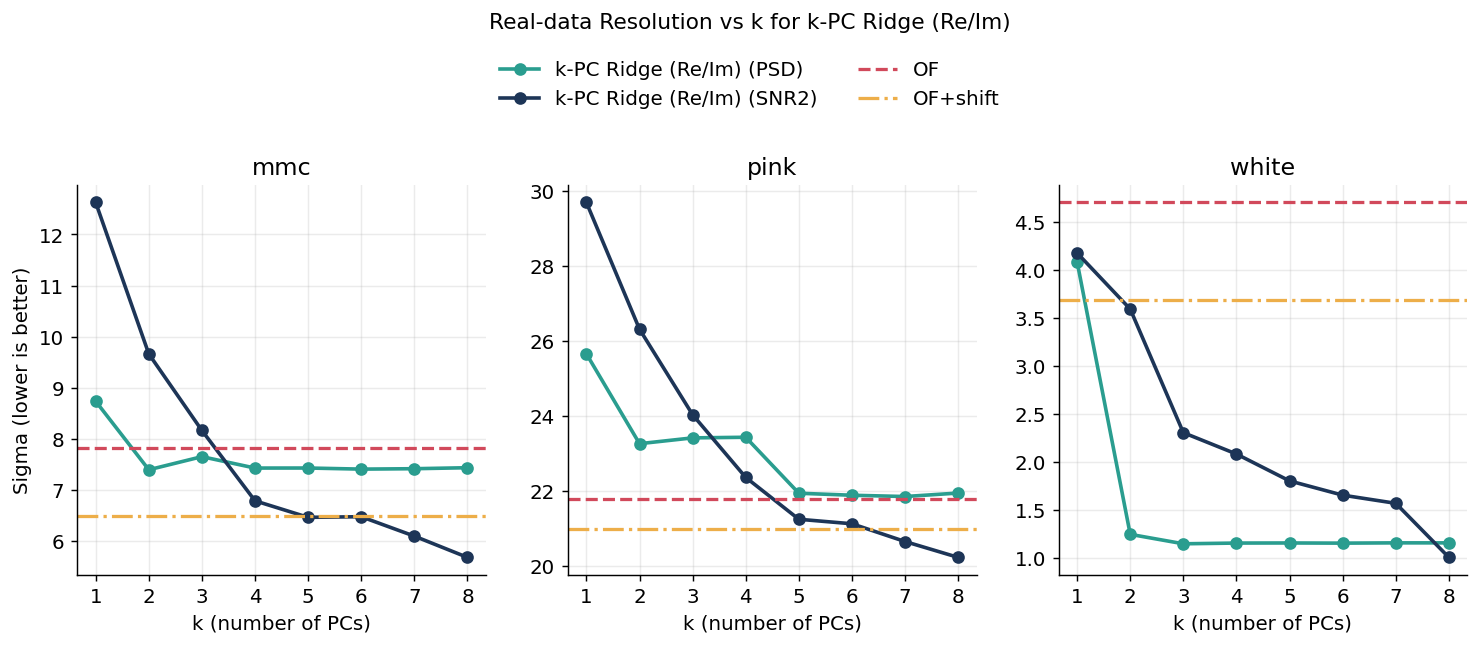

In [6]:
k_vals = sorted(df_kcurve['k'].unique())

fig, axes = plt.subplots(1, 3, figsize=(13.8, 3.9), sharey=False)
for ax, noise in zip(axes, ['mmc', 'pink', 'white']):
    for wlabel in ['PSD', 'SNR2']:
        d = df_kcurve[(df_kcurve['noise_type'] == noise) & (df_kcurve['weight_type'] == wlabel)].sort_values('k')
        if len(d) == 0:
            continue
        ax.plot(d['k'], d['sigma'], marker='o', linewidth=2.0, color=COLORS[wlabel], label=f'{METHOD_REIM} ({wlabel})')

    q_of = df_methods[(df_methods['noise_type'] == noise) & (df_methods['method'] == METHOD_OF)]
    q_ofs = df_methods[(df_methods['noise_type'] == noise) & (df_methods['method'] == METHOD_OF_SHIFT)]
    if len(q_of):
        ax.axhline(float(q_of['sigma'].iloc[0]), color=COLORS[METHOD_OF], linestyle='--', linewidth=1.8, label=METHOD_OF)
    if len(q_ofs):
        ax.axhline(float(q_ofs['sigma'].iloc[0]), color=COLORS[METHOD_OF_SHIFT], linestyle='-.', linewidth=1.8, label=METHOD_OF_SHIFT)

    ax.set_title(noise)
    ax.set_xlabel('k (number of PCs)')
    ax.set_xticks(k_vals)
    ax.grid(alpha=0.25)

axes[0].set_ylabel('Sigma (lower is better)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=2, loc='upper center', frameon=False, bbox_to_anchor=(0.5, 1.16))
fig.suptitle('Real-data Resolution vs k for k-PC Ridge (Re/Im)', y=1.22, fontsize=12)

fig.savefig(FIG_DIR / 'real_sigma_vs_k_reim.png', dpi=300)
plt.show()


## Plot 3: Diagnostic Parity + Residuals (Best REIM model)


ValueError: x and y must be the same size

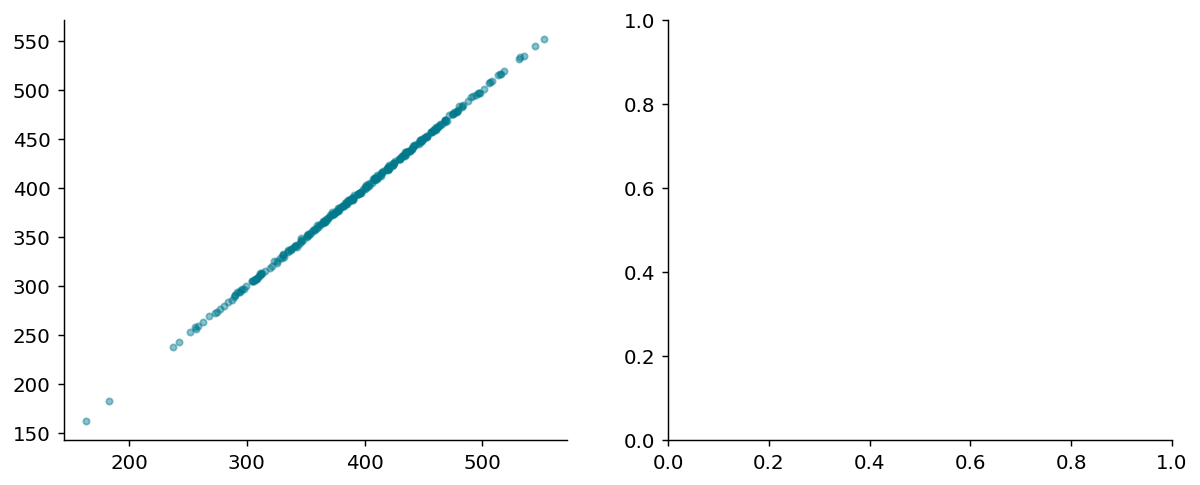

In [7]:
df_reim = df_methods[df_methods['method'] == METHOD_REIM].copy()
if len(df_reim) == 0:
    print('No REIM rows available for diagnostic plot.')
else:
    best = df_reim.sort_values('sigma').iloc[0]
    noise = best['noise_type']
    wlabel = best['weight_type']

    key_rr = (noise, wlabel, METHOD_REIM)
    if key_rr not in pred_store:
        raise RuntimeError(f'Missing prediction cache for {key_rr}')

    y_true = pred_store[key_rr]['y_true']
    y_pred_rr = pred_store[key_rr]['y_est']

    if (noise, 'OF+shift') in pred_store:
        of_label = METHOD_OF_SHIFT
        y_pred_of = pred_store[(noise, 'OF+shift')]['y_est']
    elif (noise, 'OF') in pred_store:
        of_label = METHOD_OF
        y_pred_of = pred_store[(noise, 'OF')]['y_est']
    else:
        of_label = None
        y_pred_of = None

    res_rr = y_true - y_pred_rr

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

    axes[0].scatter(y_true, y_pred_rr, s=12, alpha=0.45, color=COLORS[METHOD_REIM], label=f'{METHOD_REIM} ({wlabel})')
    if y_pred_of is not None:
        axes[0].scatter(y_true, y_pred_of, s=12, alpha=0.35, color=COLORS[of_label], label=of_label)

    lims = [0, max(float(np.max(y_true)), float(np.max(y_pred_rr)), float(np.max(y_pred_of)) if y_pred_of is not None else 0.0)]
    axes[0].plot(lims, lims, 'k--', linewidth=1.2)
    axes[0].set_xlim(lims)
    axes[0].set_ylim(lims)
    axes[0].set_xlabel('True amplitude')
    axes[0].set_ylabel('Predicted amplitude')
    axes[0].set_title(f'Parity Plot ({noise})')
    axes[0].legend(frameon=False)
    axes[0].grid(alpha=0.2)

    bins = np.linspace(-40, 40, 55)
    if y_pred_of is not None:
        res_of = y_true - y_pred_of
        axes[1].hist(res_of, bins=bins, alpha=0.45, color=COLORS[of_label], label=of_label, density=True)
    axes[1].hist(res_rr, bins=bins, alpha=0.60, color=COLORS[METHOD_REIM], label=f'{METHOD_REIM} ({wlabel})', density=True)
    axes[1].set_xlabel('Residual (true - predicted)')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Residual Distribution')
    axes[1].legend(frameon=False)
    axes[1].grid(alpha=0.2)

    fig.suptitle('Diagnostic from Best Real-data REIM Model', y=1.03)
    fig.savefig(FIG_DIR / 'real_diagnostic_parity_residual.png', dpi=300)
    plt.show()

    print('best diagnostic model:', {
        'noise_type': noise,
        'weight_type': wlabel,
        'sigma': float(best['sigma']),
        'fwhm': float(best['fwhm']),
        'k': int(best['k']),
        'alpha': float(best['alpha']),
    })


## Table Export (Markdown / LaTeX)


In [ ]:
table = (
    df_methods
    .pivot_table(index=['noise_type', 'weight_type'], columns='method', values='sigma', aggfunc='first')
    .reset_index()
)

for m in METHOD_ORDER:
    if m not in table.columns:
        table[m] = np.nan

table['OF_to_OFshift_pct'] = 100.0 * (table[METHOD_OF] - table[METHOD_OF_SHIFT]) / table[METHOD_OF]
table['OF_to_REIM_pct'] = 100.0 * (table[METHOD_OF] - table[METHOD_REIM]) / table[METHOD_OF]
table['OF_to_Euclid2_pct'] = 100.0 * (table[METHOD_OF] - table[METHOD_EUCLID2]) / table[METHOD_OF]

order = [
    'noise_type', 'weight_type',
    METHOD_OF, METHOD_OF_SHIFT, METHOD_REIM, METHOD_EUCLID2,
    'OF_to_OFshift_pct', 'OF_to_REIM_pct', 'OF_to_Euclid2_pct',
]

table = table[order].sort_values(['noise_type', 'weight_type'])

table_disp = table.copy()
for c in table_disp.columns:
    if c not in ['noise_type', 'weight_type']:
        table_disp[c] = table_disp[c].map(lambda x: f'{x:.3f}' if pd.notna(x) else 'nan')

display(table_disp)

print('Markdown table:')
print(table_disp.to_markdown(index=False))
print()
print('LaTeX table:')
print(table_disp.to_latex(index=False, escape=False))

csv_path = FIG_DIR / 'real_metrics_table.csv'
table.to_csv(csv_path, index=False)
print('saved csv:', csv_path)
